In [15]:
from autoreduce import *
import numpy as np

$ \dot{x} = f(x, \Theta) + g(x)u \\ y = Cx  \\
y = h(x, \Theta)$

In [2]:
# # Orginal two varaible

# # Post conservation law model
# n = 2
# nouts = 1 # Number of outputs
# # Either
# # sys.load_SBML_model('my_sbml_model.xml')

# # OR write ODEs
# #      x = ES, P
# #      P = a, d, k, Etot, Stot

# # parameter values
# P = np.zeros(5)
# P[0] = 10
# P[1] = 10
# P[2] = 0.1
# P[3] = 1
# P[4] = 1

# params_values = P.copy()
# timepoints_ode = np.linspace(0, 150, 100) # timepoints for simulation

# x_init = np.zeros(n) # Initial conditions

# error_tol = 100
# nstates_tol = 1
# x,f,P = load_ODE_model(n, len(params_values))
# params = P
# f[0] = P[0]*(P[3] - x[0])*(P[4] - x[0] - x[1]) - P[1]*x[0] - P[2]*x[0]
# f[1] = P[2]*x[0]
# C = np.zeros((nouts,len(x)), dtype=int)
# C[0][1] = 1
# C = C.tolist()
# sys = System(x,f,params=params,C=C, params_values=params_values,x_init=[0,0])

Took the original model code that was two-dimensional and repeated it four times to make it eight dimensional. The varable value is the same, just repeated four times over. Function Assignments follow the same pattern, with the Parameter number assignment changed to the original pattern. 

In [16]:
# Post conservation law model
n = 8
nouts = 1 # Number of outputs
# Either
# sys.load_SBML_model('my_sbml_model.xml')

# OR write ODEs
#      x = ES, P
#      P = a, d, k, Etot, Stot

# parameter values
P = np.zeros(20)
P[0] = 10  #P0
P[1] = 10  #P1
P[2] = 0.1 #P2
P[3] = 1   #P3
P[4] = 1   #P4

P[5] = 10  #P0
P[6] = 10  #P1
P[7] = 0.1 #P2
P[8] = 1   #P3
P[9] = 1   #P4

P[10] = 10  #P0
P[11] = 10  #P1
P[12] = 0.1 #P2
P[13] = 1   #P3
P[14] = 1   #P4

P[15] = 10  #P0
P[16] = 10  #P1
P[17] = 0.1 #P2
P[18] = 1   #P3
P[19] = 1   #P4

params_values = P.copy()
timepoints_ode = np.linspace(0, 150, 100) # timepoints for simulation

x_init = np.zeros(n) # Initial conditions

error_tol = 100
nstates_tol = 1
x,f,P = load_ODE_model(n, len(params_values))
params = P

f[0] = P[0]*(P[3] - x[0])*(P[4] - x[0] - x[1]) - P[1]*x[0] - P[2]*x[0]
f[1] = P[2]*x[0]

f[2] = P[5]*(P[8] - x[2])*(P[9] - x[2] - x[3]) - P[6]*x[2] - P[7]*x[2]
f[3] = P[7]*x[2]

f[4] = P[10]*(P[13] - x[4])*(P[14] - x[4] - x[5]) - P[11]*x[4] - P[12]*x[4]
f[5] = P[12]*x[4]

f[6] = P[15]*(P[18] - x[6])*(P[19] - x[6] - x[7]) - P[16]*x[6] - P[17]*x[6]
f[7] = P[17]*x[6]

C = np.zeros((nouts,len(x)), dtype=int)
C[0][1] = 1
C = C.tolist()
sys = System(x,f,params=params,C=C, params_values=params_values,x_init=[0,0,0,0,0,0,0,0])

In [4]:
#showing that using .x displays all state varaibles defined in the system
sys.x

[x0, x1, x2, x3, x4, x5, x6, x7]

In [5]:
from autoreduce.utils import get_SSM
timepoints_ssm = np.linspace(0,60,10)
sys_ssm = get_SSM(sys, timepoints_ssm)
Ss = sys_ssm.compute_SSM(normalize = True) # len(timepoints) x len(params) x len(states)
out_Ss = []
for i in range(len(params)):
    out_Ss.append((np.array(C)@(Ss[:,i,:].T)))
out_Ss = np.reshape(np.array(out_Ss), (len(timepoints_ssm), len(params), nouts))

SSM Progress: |██████████████████████████████████████████████████| 100.0% Complete


C:\Users\angel\autoreduce\autoreduce\local_sensitivity.py:257: RuntimeWarning: invalid value encountered in divide
  SSM_normalized[:, j, i] = np.divide(


In [27]:
try:
    import seaborn as sn
    for j in range(nouts):
        sn.heatmap(out_Ss[:,:,j].T)
        plt.xlabel('Time')
        plt.ylabel('Parameters')
        plt.title('Sensitivity of output[{0}] with respect to all parameters'.format(j))
        plt.show()
except:
    print('Plotting libraries missing.')

Plotting libraries missing.


In [18]:
from autoreduce.utils import get_reducible
timepoints_ssm = np.linspace(0,60,10)
timepoints_ode = np.linspace(0, 100, 100)
sys_reduce = get_reducible(sys, timepoints_ode, timepoints_ssm)
results = sys_reduce.reduce_simple(skip_numerical_computation = True,skip_error_computation = True, skip_robustness_computation = True)
#results = sys_reduce.reduce_simple()

Successful solution obtained with states: [x1]!
Successful solution obtained with states: [x0, x1]!
Could not find solution for: x3 from P7*x2


C:\Users\angel\autoreduce\autoreduce\model_reduction.py:1215: UserWarning: Solve time-scale separation failed. Check model consistency.
  warnings.warn(


Could not find solution for: x3 from P7*x2
Could not find solution for: x3 from P7*x2
Could not find solution for: x3 from P7*x2
Did not work to retain: [x1, x2] because either a collapsed state-variables appears
 in the reduced model or a solution is not possible.


C:\Users\angel\autoreduce\autoreduce\model_reduction.py:470: UserWarning: Solve time-scale separation failed.Check model consistency.
  warnings.warn(


Successful solution obtained with states: [x1, x3]!
Could not find solution for: x5 from P12*x4
Could not find solution for: x5 from P12*x4
Could not find solution for: x5 from P12*x4
Could not find solution for: x5 from P12*x4
Did not work to retain: [x1, x4] because either a collapsed state-variables appears
 in the reduced model or a solution is not possible.
Successful solution obtained with states: [x1, x5]!
Could not find solution for: x7 from P17*x6
Could not find solution for: x7 from P17*x6
Could not find solution for: x7 from P17*x6
Could not find solution for: x7 from P17*x6
Did not work to retain: [x1, x6] because either a collapsed state-variables appears
 in the reduced model or a solution is not possible.
Successful solution obtained with states: [x1, x7]!
Could not find solution for: x3 from P7*x2
Could not find solution for: x3 from P7*x2
Could not find solution for: x3 from P7*x2
Could not find solution for: x3 from P7*x2
Did not work to retain: [x0, x1, x2] because e

This part below, I manually calculated all the reduced dimension models and kept only the succesfully reduced models. 

Naming: reduced_system(# of dimensions/states reduced to)d(variable # assignment)

In [19]:
reduced_system_1d1, _ = sys_reduce.solve_timescale_separation([x[1]])
reduced_system_1d2, _ = sys_reduce.solve_timescale_separation([x[3]])
reduced_system_1d3, _ = sys_reduce.solve_timescale_separation([x[5]])
reduced_system_1d4, _ = sys_reduce.solve_timescale_separation([x[7]])

reduced_system_2d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1]])
reduced_system_2d2, _ = sys_reduce.solve_timescale_separation([x[1], x[3]])
reduced_system_2d3, _ = sys_reduce.solve_timescale_separation([x[1], x[5]])
reduced_system_2d4, _ = sys_reduce.solve_timescale_separation([x[1], x[7]])
reduced_system_2d5, _ = sys_reduce.solve_timescale_separation([x[2], x[3]])
reduced_system_2d6, _ = sys_reduce.solve_timescale_separation([x[3], x[5]])
reduced_system_2d7, _ = sys_reduce.solve_timescale_separation([x[3], x[7]])
reduced_system_2d8, _ = sys_reduce.solve_timescale_separation([x[4], x[5]])
reduced_system_2d9, _ = sys_reduce.solve_timescale_separation([x[5], x[7]])
reduced_system_2d10, _ = sys_reduce.solve_timescale_separation([x[6], x[7]])

reduced_system_3d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3]])
reduced_system_3d2, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[5]])
reduced_system_3d3, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[7]])
reduced_system_3d4, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3]])
reduced_system_3d5, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[5]])
reduced_system_3d6, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[7]])
reduced_system_3d7, _ = sys_reduce.solve_timescale_separation([x[1], x[4], x[5]])
reduced_system_3d8, _ = sys_reduce.solve_timescale_separation([x[1], x[5], x[7]])
reduced_system_3d9, _ = sys_reduce.solve_timescale_separation([x[1], x[6], x[7]])
reduced_system_3d10, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[5]])
reduced_system_3d11, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[7]])
reduced_system_3d12, _ = sys_reduce.solve_timescale_separation([x[3], x[4], x[5]])
reduced_system_3d13, _ = sys_reduce.solve_timescale_separation([x[3], x[5], x[7]])
reduced_system_3d14, _ = sys_reduce.solve_timescale_separation([x[3], x[6], x[7]])
reduced_system_3d15, _ = sys_reduce.solve_timescale_separation([x[4], x[5], x[7]])
reduced_system_3d16, _ = sys_reduce.solve_timescale_separation([x[5], x[6], x[7]])

reduced_system_4d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3]])
reduced_system_4d2, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[5]])
reduced_system_4d3, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[7]])
reduced_system_4d4, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[4], x[5]])
reduced_system_4d5, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[5], x[7]])
reduced_system_4d6, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[6], x[7]])
reduced_system_4d7, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[5]])
reduced_system_4d8, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[7]])
reduced_system_4d9, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[4], x[5]])
reduced_system_4d10, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[5], x[7]])
reduced_system_4d11, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[6], x[7]])
reduced_system_4d12, _ = sys_reduce.solve_timescale_separation([x[1], x[4], x[5], x[7]])
reduced_system_4d13, _ = sys_reduce.solve_timescale_separation([x[1], x[5], x[6], x[7]])
reduced_system_4d14, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[4], x[5]])
reduced_system_4d15, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[5], x[7]])
reduced_system_4d16, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[6], x[7]])
reduced_system_4d17, _ = sys_reduce.solve_timescale_separation([x[3], x[4], x[5], x[7]])
reduced_system_4d18, _ = sys_reduce.solve_timescale_separation([x[3], x[5], x[6], x[7]])
reduced_system_4d19, _ = sys_reduce.solve_timescale_separation([x[4], x[5], x[6], x[7]])

reduced_system_5d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3], x[5]])
reduced_system_5d2, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3], x[7]])
reduced_system_5d3, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[4], x[5]])
reduced_system_5d4, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[5], x[7]])
reduced_system_5d5, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[6], x[7]])
reduced_system_5d6, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[4], x[5], x[7]])
reduced_system_5d7, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[5], x[6], x[7]])
reduced_system_5d8, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[4], x[5]])
reduced_system_5d9, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[5], x[7]])
reduced_system_5d10, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[6], x[7]])
reduced_system_5d11, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[4], x[5], x[7]])
reduced_system_5d12, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[5], x[6], x[7]])
reduced_system_5d13, _ = sys_reduce.solve_timescale_separation([x[1], x[4], x[5], x[6], x[7]])
reduced_system_5d14, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[4], x[5], x[7]])
reduced_system_5d15, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[5], x[6], x[7]])
reduced_system_5d16, _ = sys_reduce.solve_timescale_separation([x[3], x[4], x[5], x[6], x[7]])

reduced_system_6d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3], x[4], x[5]])
reduced_system_6d2, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3], x[5], x[7]])
reduced_system_6d3, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3], x[6], x[7]])
reduced_system_6d4, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[4], x[5], x[7]])
reduced_system_6d5, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[5], x[6], x[7]])
reduced_system_6d6, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[4], x[5], x[6], x[7]])
reduced_system_6d7, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[4], x[5], x[7]])
reduced_system_6d8, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[5], x[6], x[7]])
reduced_system_6d9, _ = sys_reduce.solve_timescale_separation([x[1], x[3], x[4], x[5], x[6], x[7]])
reduced_system_6d10, _ = sys_reduce.solve_timescale_separation([x[2], x[3], x[4], x[5], x[6], x[7]])

reduced_system_7d1, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3], x[4], x[5], x[7]])
reduced_system_7d2, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[2], x[3], x[5], x[6], x[7]])
reduced_system_7d3, _ = sys_reduce.solve_timescale_separation([x[0], x[1], x[3], x[4], x[5], x[6], x[7]])
reduced_system_7d4, _ = sys_reduce.solve_timescale_separation([x[1], x[2], x[3], x[4], x[5], x[6], x[7]])

Successful solution obtained with states: [x1]!
Successful solution obtained with states: [x3]!
Successful solution obtained with states: [x5]!
Successful solution obtained with states: [x7]!
Successful solution obtained with states: [x0, x1]!
Successful solution obtained with states: [x1, x3]!
Successful solution obtained with states: [x1, x5]!
Successful solution obtained with states: [x1, x7]!
Successful solution obtained with states: [x2, x3]!
Successful solution obtained with states: [x3, x5]!
Successful solution obtained with states: [x3, x7]!
Successful solution obtained with states: [x4, x5]!
Successful solution obtained with states: [x5, x7]!
Successful solution obtained with states: [x6, x7]!
Successful solution obtained with states: [x0, x1, x3]!
Successful solution obtained with states: [x0, x1, x5]!
Successful solution obtained with states: [x0, x1, x7]!
Successful solution obtained with states: [x1, x2, x3]!
Successful solution obtained with states: [x1, x3, x5]!
Successf

Below is code for displaying the reduced model in easier to read LaTex form

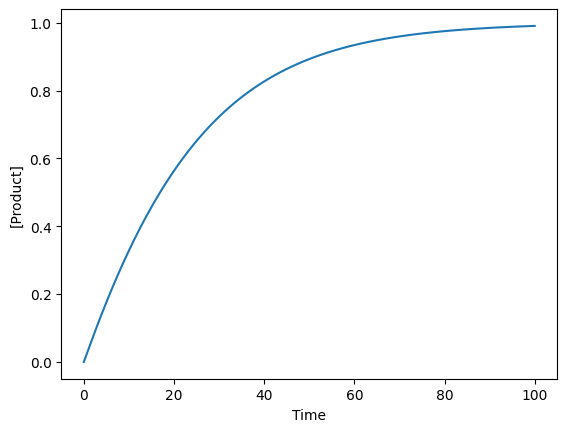

In [20]:
#moved the plotting of the original system to here so I can compare

from autoreduce.utils import get_ODE
sys_ode = get_ODE(sys, timepoints_ode)
sol = sys_ode.solve_system().T
#try:
import matplotlib.pyplot as plt
plt.plot(timepoints_ode, np.transpose(np.array(C)@sol))
plt.xlabel('Time')
plt.ylabel('[Product]')
plt.show()
#except:
#    print('Plotting libraries missing.')

Used the Generate function to plot all the reduced models compared to the orginal model (dotted line), color coded based on how close the behavior is to the original. The legend is also organized by their MAE

C:\Users\angel\AppData\Local\Temp\ipykernel_34712\400505465.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn_r")


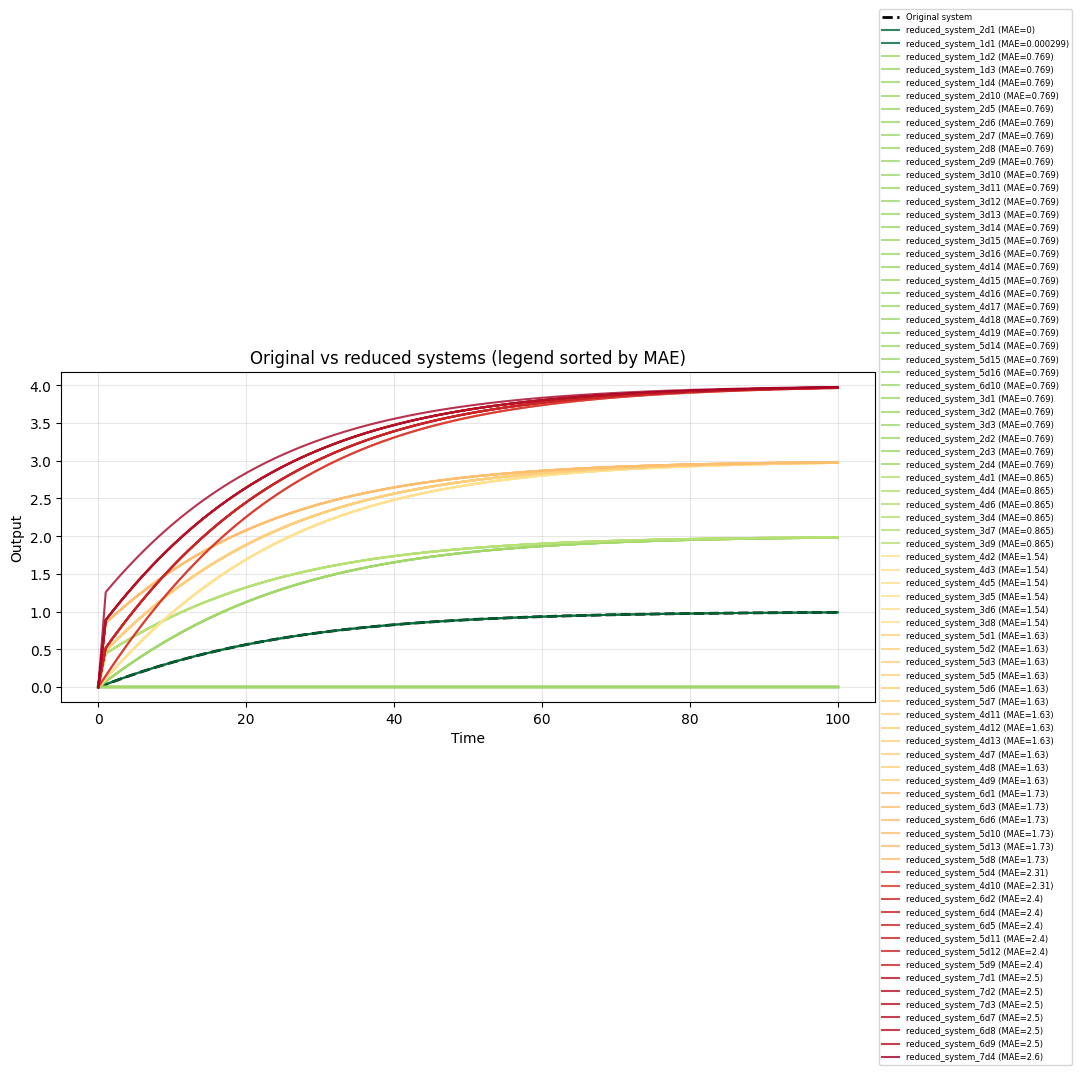

In [21]:
reduced_systems = [
    (name, obj)
    for name, obj in globals().items()
    if name.startswith("reduced_system_")
]
reduced_systems.sort(key=lambda x: x[0])

orig_output = np.transpose(np.array(C) @ sol)
if orig_output.ndim == 1:
    orig_output = orig_output[:, None]

reduced_results = []
for name, reduced_sys in reduced_systems:
    try:
        sys_reduced_ode = get_ODE(reduced_sys, timepoints_ode)
        sol_reduced = sys_reduced_ode.solve_system().T
        C_reduced = np.array(reduced_sys.C)
        reduced_output = np.transpose(C_reduced @ sol_reduced)
        if reduced_output.ndim == 1:
            reduced_output = reduced_output[:, None]

        mae = np.mean(np.abs(orig_output[:, 0] - reduced_output[:, 0]))
        reduced_results.append((name, reduced_output[:, 0], mae))
    except Exception:
        continue

if not reduced_results:
    raise RuntimeError("No reduced systems available to plot.")

reduced_results.sort(key=lambda item: item[2])

mae_values = [item[2] for item in reduced_results]
norm = plt.Normalize(min(mae_values), max(mae_values))
cmap = plt.cm.get_cmap("RdYlGn_r")

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(timepoints_ode, orig_output[:, 0], "k--", linewidth=2, label="Original system")

for name, reduced_output, mae in reduced_results:
    ax.plot(
        timepoints_ode,
        reduced_output,
        color=cmap(norm(mae)),
        alpha=0.8,
        label=f"{name} (MAE={mae:.3g})",
    )

ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.set_title("Original vs reduced systems (legend sorted by MAE)")
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=6)
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

In [ ]:
#asked claude to use plotly to plot the graph above
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

reduced_systems = [
    (name, obj)
    for name, obj in globals().items()
    if name.startswith("reduced_system_")
]
reduced_systems.sort(key=lambda x: x[0])

orig_output = np.transpose(np.array(C) @ sol)
if orig_output.ndim == 1:
    orig_output = orig_output[:, None]

reduced_results = []
for name, reduced_sys in reduced_systems:
    try:
        sys_reduced_ode = get_ODE(reduced_sys, timepoints_ode)
        sol_reduced = sys_reduced_ode.solve_system().T
        C_reduced = np.array(reduced_sys.C)
        reduced_output = np.transpose(C_reduced @ sol_reduced)
        if reduced_output.ndim == 1:
            reduced_output = reduced_output[:, None]

        mae = np.mean(np.abs(orig_output[:, 0] - reduced_output[:, 0]))
        reduced_results.append((name, reduced_output[:, 0], mae))
    except Exception:
        continue

if not reduced_results:
    raise RuntimeError("No reduced systems available to plot.")

reduced_results.sort(key=lambda item: item[2])

mae_values = np.array([item[2] for item in reduced_results])
mae_min, mae_max = mae_values.min(), mae_values.max()
mae_norm = (mae_values - mae_min) / (mae_max - mae_min + 1e-12)

# Map normalized MAE -> RdYlGn_r colorscale (green=low error, red=high error)
colors = px.colors.sample_colorscale("RdYlGn_r", mae_norm.tolist())

fig = go.Figure()

# Original system (dashed black)
fig.add_trace(go.Scatter(
    x=timepoints_ode,
    y=orig_output[:, 0],
    mode="lines",
    name="Original system",
    line=dict(color="black", dash="dash", width=3),
))

# Reduced systems
for (name, reduced_output, mae), color in zip(reduced_results, colors):
    fig.add_trace(go.Scatter(
        x=timepoints_ode,
        y=reduced_output,
        mode="lines",
        name=f"{name} (MAE={mae:.3g})",
        line=dict(color=color, width=1.5),
        opacity=0.8,
    ))

fig.update_layout(
    title="Original vs reduced systems (legend sorted by MAE)",
    xaxis_title="Time",
    yaxis_title="Output",
    legend=dict(font=dict(size=9), yanchor="middle", y=0.5, xanchor="left", x=1.02),
    width=1100,
    height=650,
    margin=dict(r=300),  # room for the legend on the right
    template="plotly_white",
)

fig.show()

It was hard to see all of it, so I made 7 different plots divided by dimension.

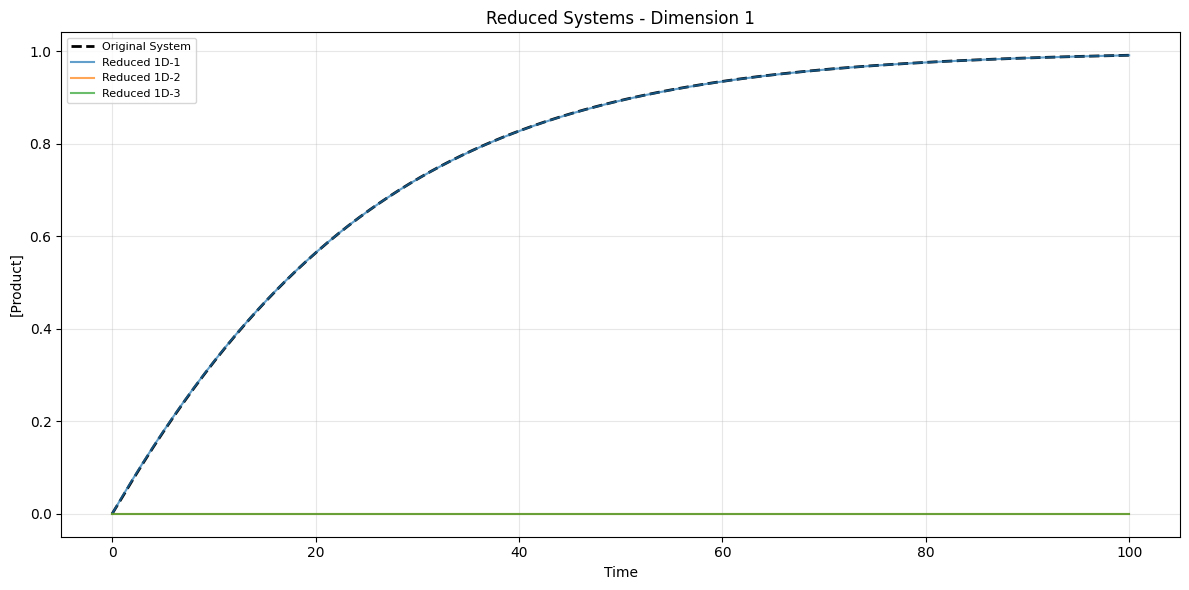

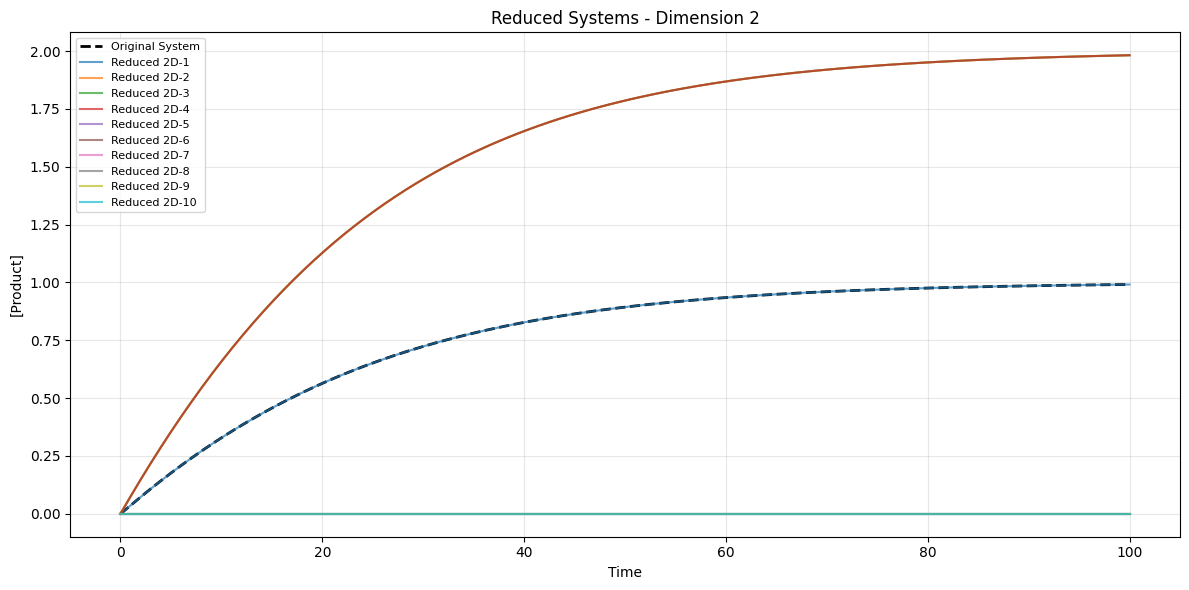

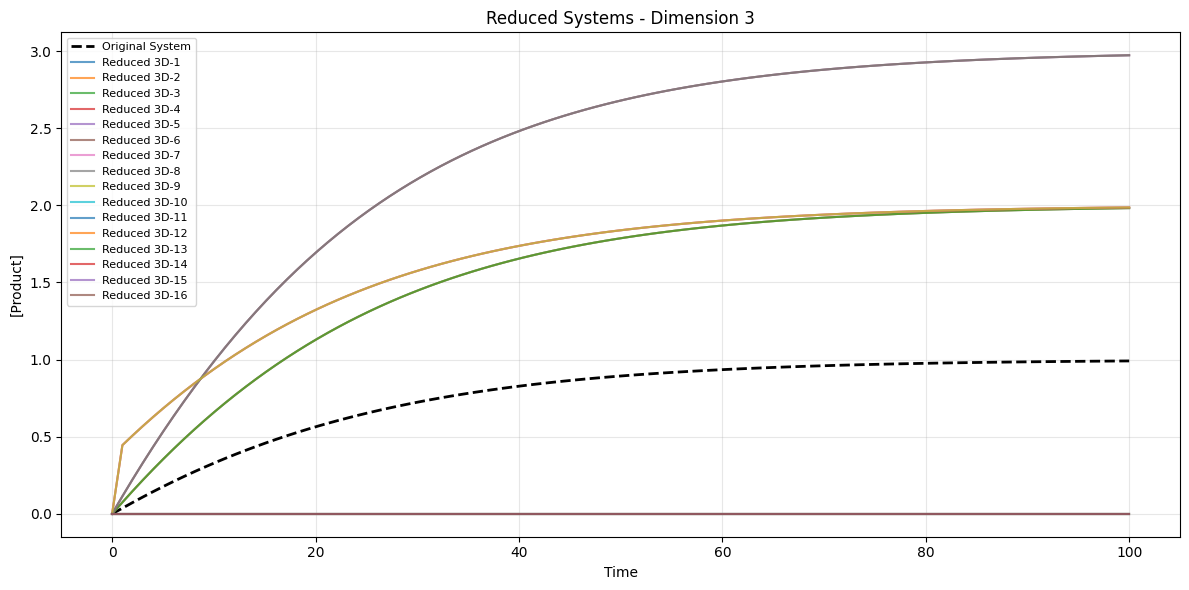

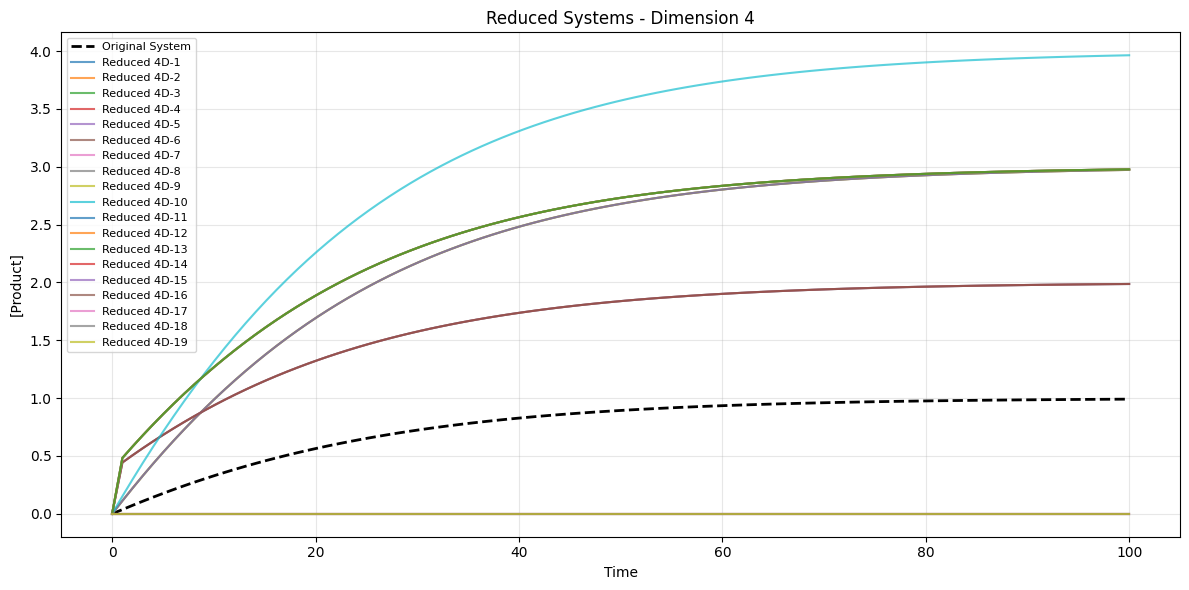

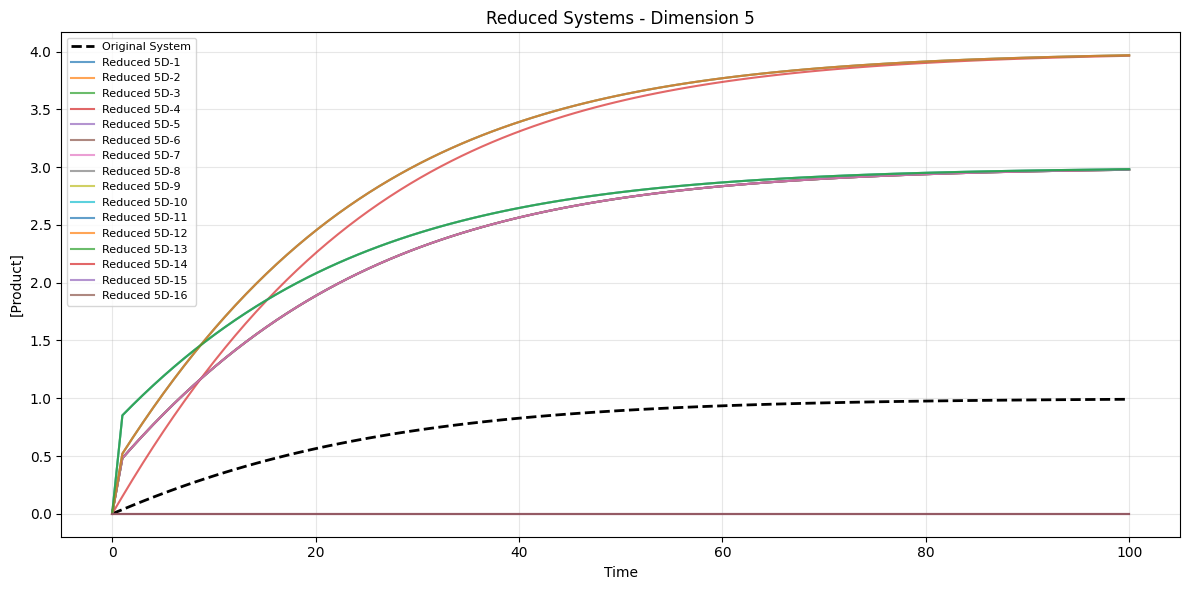

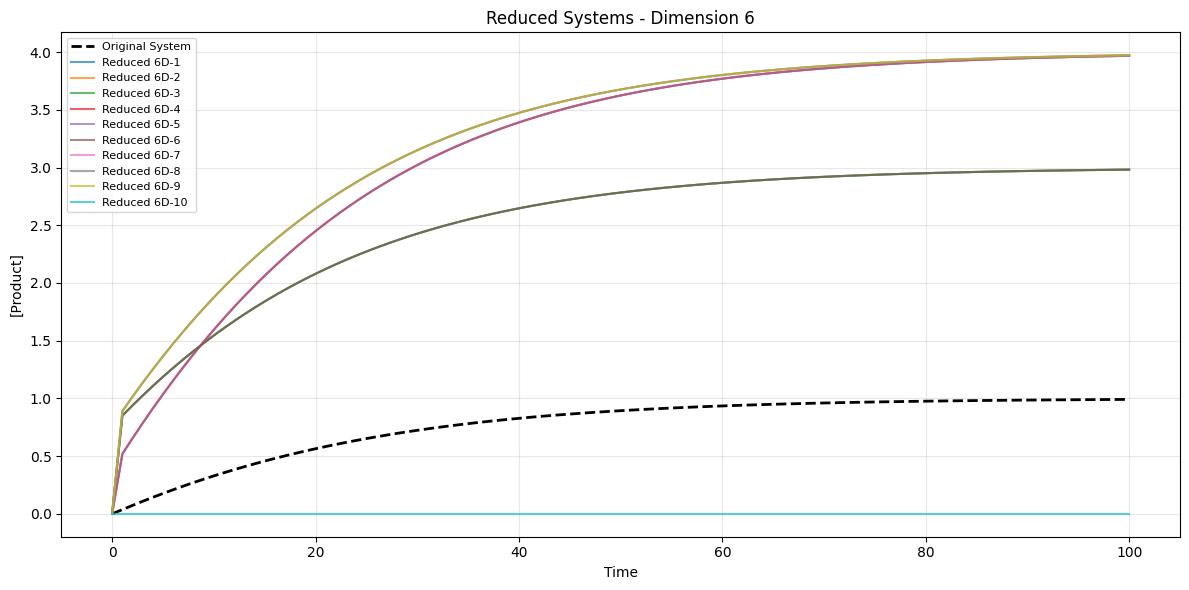

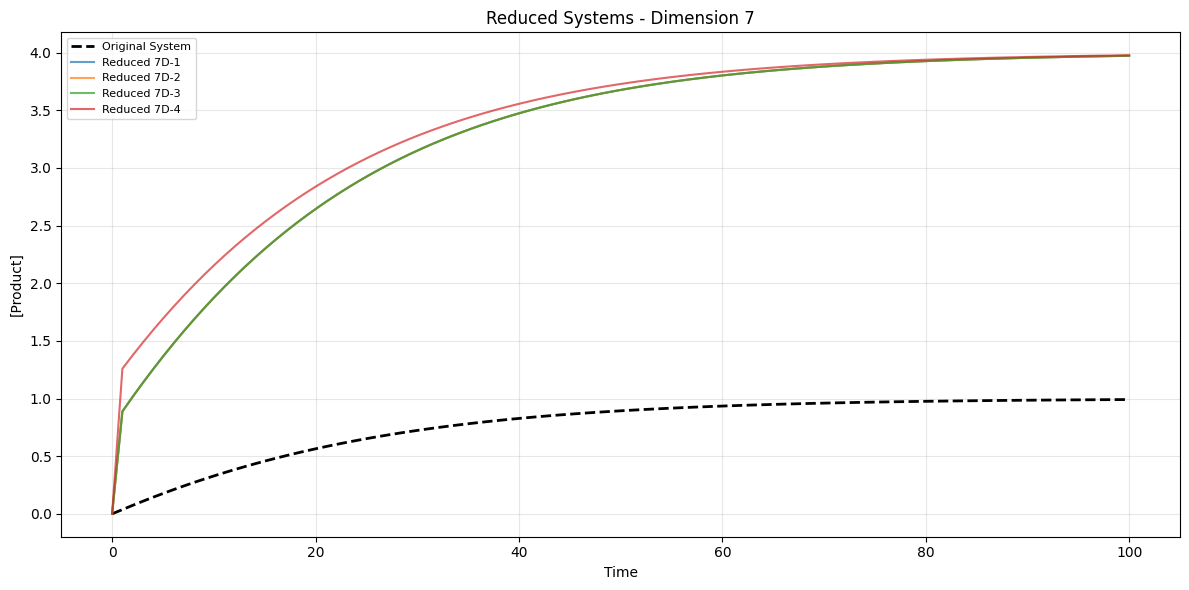

In [22]:
import matplotlib.pyplot as plt

# Organize reduced systems by dimension
systems_by_dim = {
    1: [reduced_system_1d1, reduced_system_1d2, reduced_system_1d3],
    2: [reduced_system_2d1, reduced_system_2d2, reduced_system_2d3, reduced_system_2d4,
        reduced_system_2d5, reduced_system_2d6, reduced_system_2d7, reduced_system_2d8,
        reduced_system_2d9, reduced_system_2d10],
    3: [reduced_system_3d1, reduced_system_3d2, reduced_system_3d3, reduced_system_3d4,
        reduced_system_3d5, reduced_system_3d6, reduced_system_3d7, reduced_system_3d8,
        reduced_system_3d9, reduced_system_3d10, reduced_system_3d11, reduced_system_3d12,
        reduced_system_3d13, reduced_system_3d14, reduced_system_3d15, reduced_system_3d16],
    4: [reduced_system_4d1, reduced_system_4d2, reduced_system_4d3, reduced_system_4d4,
        reduced_system_4d5, reduced_system_4d6, reduced_system_4d7, reduced_system_4d8,
        reduced_system_4d9, reduced_system_4d10, reduced_system_4d11, reduced_system_4d12,
        reduced_system_4d13, reduced_system_4d14, reduced_system_4d15, reduced_system_4d16,
        reduced_system_4d17, reduced_system_4d18, reduced_system_4d19],
    5: [reduced_system_5d1, reduced_system_5d2, reduced_system_5d3, reduced_system_5d4,
        reduced_system_5d5, reduced_system_5d6, reduced_system_5d7, reduced_system_5d8,
        reduced_system_5d9, reduced_system_5d10, reduced_system_5d11, reduced_system_5d12,
        reduced_system_5d13, reduced_system_5d14, reduced_system_5d15, reduced_system_5d16],
    6: [reduced_system_6d1, reduced_system_6d2, reduced_system_6d3, reduced_system_6d4,
        reduced_system_6d5, reduced_system_6d6, reduced_system_6d7, reduced_system_6d8,
        reduced_system_6d9, reduced_system_6d10],
    7: [reduced_system_7d1, reduced_system_7d2, reduced_system_7d3, reduced_system_7d4]
}

# Plot each dimension
for dim in sorted(systems_by_dim.keys()):
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot original system as dotted line
    ax.plot(timepoints_ode, np.transpose(np.array(C) @ sol), 'k--', linewidth=2, label='Original System')

    # Plot each reduced system for this dimension
    for i, reduced_sys in enumerate(systems_by_dim[dim]):
        sys_ode_temp = get_ODE(reduced_sys, timepoints_ode)
        sol_temp = sys_ode_temp.solve_system().T
        C_reduced = np.array(reduced_sys.C)
        ax.plot(timepoints_ode, np.transpose(C_reduced @ sol_temp), label=f'Reduced {dim}D-{i+1}', alpha=0.7)

    ax.set_xlabel('Time')
    ax.set_ylabel('[Product]')
    ax.set_title(f'Reduced Systems - Dimension {dim}')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [25]:
#same with this one, imported the code to plotly
import plotly.graph_objects as go
import numpy as np

# Organize reduced systems by dimension
systems_by_dim = {
    1: [reduced_system_1d1, reduced_system_1d2, reduced_system_1d3],
    2: [reduced_system_2d1, reduced_system_2d2, reduced_system_2d3, reduced_system_2d4,
        reduced_system_2d5, reduced_system_2d6, reduced_system_2d7, reduced_system_2d8,
        reduced_system_2d9, reduced_system_2d10],
    3: [reduced_system_3d1, reduced_system_3d2, reduced_system_3d3, reduced_system_3d4,
        reduced_system_3d5, reduced_system_3d6, reduced_system_3d7, reduced_system_3d8,
        reduced_system_3d9, reduced_system_3d10, reduced_system_3d11, reduced_system_3d12,
        reduced_system_3d13, reduced_system_3d14, reduced_system_3d15, reduced_system_3d16],
    4: [reduced_system_4d1, reduced_system_4d2, reduced_system_4d3, reduced_system_4d4,
        reduced_system_4d5, reduced_system_4d6, reduced_system_4d7, reduced_system_4d8,
        reduced_system_4d9, reduced_system_4d10, reduced_system_4d11, reduced_system_4d12,
        reduced_system_4d13, reduced_system_4d14, reduced_system_4d15, reduced_system_4d16,
        reduced_system_4d17, reduced_system_4d18, reduced_system_4d19],
    5: [reduced_system_5d1, reduced_system_5d2, reduced_system_5d3, reduced_system_5d4,
        reduced_system_5d5, reduced_system_5d6, reduced_system_5d7, reduced_system_5d8,
        reduced_system_5d9, reduced_system_5d10, reduced_system_5d11, reduced_system_5d12,
        reduced_system_5d13, reduced_system_5d14, reduced_system_5d15, reduced_system_5d16],
    6: [reduced_system_6d1, reduced_system_6d2, reduced_system_6d3, reduced_system_6d4,
        reduced_system_6d5, reduced_system_6d6, reduced_system_6d7, reduced_system_6d8,
        reduced_system_6d9, reduced_system_6d10],
    7: [reduced_system_7d1, reduced_system_7d2, reduced_system_7d3, reduced_system_7d4]
}

orig_output = np.transpose(np.array(C) @ sol)
if orig_output.ndim > 1:
    orig_output = orig_output[:, 0]

# Plot each dimension
for dim in sorted(systems_by_dim.keys()):
    fig = go.Figure()

    # Original system as dashed black line
    fig.add_trace(go.Scatter(
        x=timepoints_ode,
        y=orig_output,
        mode="lines",
        name="Original System",
        line=dict(color="black", dash="dash", width=2),
    ))

    # Reduced systems for this dimension
    for i, reduced_sys in enumerate(systems_by_dim[dim]):
        sys_ode_temp = get_ODE(reduced_sys, timepoints_ode)
        sol_temp = sys_ode_temp.solve_system().T
        C_reduced = np.array(reduced_sys.C)
        reduced_output = np.transpose(C_reduced @ sol_temp)
        if reduced_output.ndim > 1:
            reduced_output = reduced_output[:, 0]

        fig.add_trace(go.Scatter(
            x=timepoints_ode,
            y=reduced_output,
            mode="lines",
            name=f"Reduced {dim}D-{i+1}",
            opacity=0.7,
        ))

    fig.update_layout(
        title=f"Reduced Systems - Dimension {dim}",
        xaxis_title="Time",
        yaxis_title="[Product]",
        legend=dict(font=dict(size=9)),
        width=900,
        height=550,
        template="plotly_white",
    )

    fig.show()

This displays all the reduced system equations in an easier to read LaTex format.

In [ ]:
from IPython.display import display, Math
from sympy import latex
import re

for name, value in sorted(globals().items()):
    if re.match(r"reduced_system_\d+d\d+$", name):
        display(Math(r"\Large \text{" + name.replace("_", r"\_") + "}"))
        display(Math(latex(value.f)))
        display(Math(r"\text{------------------------------------}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The reduced models that best fit the orginal equation is 2d1 & 1d1 (with a Mean Absolute Error of 0 & 0.0002). I decided to print out the orignal model & these two models below

In [ ]:
#.f prints out the orginal function
sys.f

[P0*(P3 - x0)*(P4 - x0 - x1) - P1*x0 - P2*x0,
 P2*x0,
 P5*(P8 - x2)*(P9 - x2 - x3) - P6*x2 - P7*x2,
 P7*x2,
 P10*(P13 - x4)*(P14 - x4 - x5) - P11*x4 - P12*x4,
 P12*x4,
 P15*(P18 - x6)*(P19 - x6 - x7) - P16*x6 - P17*x6,
 P17*x6]

In [23]:
reduced_system_1d1.f

[P2*(P0*P3 + P0*P4 - P0*x1 + P1 + P2 - sqrt(P0**2*P3**2 - 2*P0**2*P3*P4 + 2*P0**2*P3*x1 + P0**2*P4**2 - 2*P0**2*P4*x1 + P0**2*x1**2 + 2*P0*P1*P3 + 2*P0*P1*P4 - 2*P0*P1*x1 + 2*P0*P2*P3 + 2*P0*P2*P4 - 2*P0*P2*x1 + P1**2 + 2*P1*P2 + P2**2))/(2*P0)]

In [ ]:
from IPython.display import display, Math

#title + equation
display(Math(r"\text{Original System: } " + latex(sys.f)))
display(Math(r"\text{Reduced System 1d1: } " + latex(reduced_system_1d1.f)))
display(Math(r"\text{Reduced System 2d1: } " + latex(reduced_system_2d1.f)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

*Note: the code below only works if you run reduce_simple() in block 44 fully

In [ ]:
err = results[list(results.keys())[0]][0]
Se = results[list(results.keys())[0]][1]
weighted_se = 0
for p, Se_i in zip(params_values, Se):
    weighted_se += p*Se_i

In [ ]:
d_R = weighted_se/err
d_R

np.float64(19058467.857970025)

In [ ]:
w1 = 1
w2 = 1e-3
r = w1*err + w2*d_R
r

np.float64(19058.472081797747)

In [ ]:
slow_system, fast_system = sys_reduce.solve_timescale_separation([x[1]])
slow_system.f[0]

Successful solution obtained with states: [x1]!


P2*(P0*P3 + P0*P4 - P0*x1 + P1 + P2 - sqrt(P0**2*P3**2 - 2*P0**2*P3*P4 + 2*P0**2*P3*x1 + P0**2*P4**2 - 2*P0**2*P4*x1 + P0**2*x1**2 + 2*P0*P1*P3 + 2*P0*P1*P4 - 2*P0*P1*x1 + 2*P0*P2*P3 + 2*P0*P2*P4 - 2*P0*P2*x1 + P1**2 + 2*P1*P2 + P2**2))/(2*P0)